## Grupo 1 | MCDI500 - Programación para la ciencia de datos

### Integrantes

- Pablo Ignacio Balbontin Constenla @pabbalbontin-maker
- Melany Esmeralda Reyes Leiva @melanyreyesy
- Ingeborg Andrea Munoz Carnot @dark452
- Mario Alejandro Lopez Pulgar @malp2203

### 1. Descripción del proyecto - Fase 3
El objetivo del proyecto es realizar un análisis del impacto la utilización y frecuencia de uso de la IA generativa sobre el rendimiento académico y el nivel de agotamiento de estudiantes universitarios. 

En esta fase se refactoriza el pipeline de preprocesamiento de la Fase 2 a **Programación Orientada a Objetos (POO)**, se define y resuelve un **problema algorítmico** sobre el dataset, y se mide la complejidad computacional de las soluciones con `timeit`.

**Pregunta de investigación algorítmica:**

Seleccionamos el siguiente problema a solucionar con algorítmos recursivos: 
¿Qué estudiantes presentan perfil de mayor riesgo académico?
 **Criterio de riesgo**:
        - Burnout_Risk_Level = 2 (High)
        - Post_Semester_GPA  ≤ umbral_gpa (por defecto: percentil 25 del dataset)
        - Weekly_GenAI_Hours ≥ umbral_ia  (por defecto: percentil 75 del dataset)

#### 1.1 Objetivos Específicos
- Refactorizar las funciones del notebook de la fase 2 a `src/functions.py`, luego importar en el notebook y simplificar su implementación.
- Implementar búsqueda lineal O(n) y vectorizada, y Merge Sort recursivo O(n log n), para solucionar el problema seleccionado.
- Comparar tiempos de ejecución con `timeit` e interpretar la complejidad Big-O.
- Validar el pipeline con casos normales, límite y excepciones.
- Encapsular el pipeline de fase 2 en clases con herencia, polimorfismo y encapsulamiento.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
%load_ext autoreload
%autoreload 2
np.random.seed(42)
ruta_src = os.path.abspath(os.path.join("..", "src"))

if ruta_src not in sys.path:
    sys.path.append(ruta_src)
              
from functions import (load_data,show_tipos,show_nulos,show_estadisticas,mostrar_boxplots,
    detectar_outliers,show_categories,compute_skewness,drop_id_column,cast_bool_to_int,
    encode_ordinal,codificar_one_hot,escalar_caracteristicas,export_processed, COLUMNAS_NUMERICAS,
    COLS_STANDARD,COLS_MINMAX
)

from gestor_datos import GestorDatos
from transformador import (
    Transformador, EliminadorColumna, CastBooleano,
    CodificadorOrdinal, CodificadorOneHot,
    EscaladoZScore, EscaladoMinMax
)
from preprocesador import Preprocesador, Pipeline

print("[OK] Librerías y módulos importados correctamente.")
print(f"     Python  : {sys.version.split()[0]}")
print(f"     pandas  : {pd.__version__}")
print(f"     numpy   : {np.__version__}")

[OK] Librerías y módulos importados correctamente.
     Python  : 3.12.5
     pandas  : 2.2.3
     numpy   : 1.26.4


## 2. Refactorización de funciones de fase 2
### 2.1 Función Carga de dataset
Carga el dataset raw desde la ruta relativa indicada utilizando `pd.read_csv`. Si la ruta no existe lanza `FileNotFoundError` con mensaje descriptivo.

In [2]:
df = load_data('../data/raw/ai_student_impact_dataset.csv')
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 50,000 filas x 16 columnas


### 2.2 Columnas Numéricas

Se crean listas con las variables numéricas del dataset, estas variable serán utilizada por funciones en las siguientes secciones.

In [3]:
# Imprimimos las variables
print(f"Numéricas:\n{COLUMNAS_NUMERICAS}\n\nEstándar:\n{COLS_STANDARD}\n\nMínimo y Máximo:\n{COLS_MINMAX}")

Numéricas:
['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']

Estándar:
['Pre_Semester_GPA', 'Traditional_Study_Hours', 'Post_Semester_GPA', 'Skill_Retention_Score']

Mínimo y Máximo:
['Weekly_GenAI_Hours', 'Tool_Diversity', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']


### 2.3 Análisis Exploratorio de Datos (EDA)

Antes de transformar cualquier variable se realiza una inspección completa del dataset. El objetivo es entender la estructura, detectar problemas de calidad y fundamentar las decisiones de limpieza y transformación.

#### 2.3.1 Dimensiones y tipos de datos

La función `show_tipos` muestra:

1. **Dimensiones** (`shape`): Cantidad de columnas y filas
2. **Tipos de datos** (`dtypes`): Qué columnas son numéricas y cuáles son texto. Las de texto `object` son las que se codificarán más adelante.

In [4]:
show_tipos(df)

Dimensiones: (50000, 16)

Columna                     Tipo Dato
-------------------------------------
Student_ID                      int64
Major_Category                 object
Year_of_Study                  object
Pre_Semester_GPA              float64
Weekly_GenAI_Hours            float64
Primary_Use_Case               object
Prompt_Engineering_Skill       object
Tool_Diversity                  int64
Paid_Subscription                bool
Traditional_Study_Hours       float64
Perceived_AI_Dependency         int64
Institutional_Policy           object
Anxiety_Level_During_Exams      int64
Post_Semester_GPA             float64
Skill_Retention_Score         float64
Burnout_Risk_Level             object
dtype: object



#### 2.3.2 Valores nulos

La función `show_nulos` muestra cuántos datos faltan en cada columna y su porcentaje. Se espera confirmar que el dataset no contiene valores nulos, según lo declarado en la Fase 1.

**Estrategia de imputación (si se detectarán nulos):**
- Variables numéricas continuas: imputación por mediana.
- Variables categóricas: imputación por moda o creación de categoría `Desconocido`.

In [5]:
show_nulos(df)

Valores nulos por columna:
-------------------------------
Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64



#### 2.3.3 Estadísticas descriptivas

Estadísticas descriptivas (`describe()`): Media, mínimo, máximo, etc., de las variables numéricas, útil para detectar rangos raros o valores atípicos.

La función `show_estadisticas` muestra un resumen de las columnas numéricas:
- `count`: cantidad de valores no nulos
- `mean`: promedio
- `std`: desviación estándar
- `min` / `max`: valores extremos
- `25%`, `50%`, `75%`: cuartiles

In [6]:
show_estadisticas(df)

Estadísticas descriptivas:
-------------------------------
          Student_ID  Pre_Semester_GPA  Weekly_GenAI_Hours  Tool_Diversity  \
count   50000.000000      50000.000000        50000.000000     50000.00000   
mean   125000.500000          3.146102            8.427752         2.80026   
std     14433.901067          0.478854            8.269490         1.18802   
min    100001.000000          1.183000            0.000000         1.00000   
25%    112500.750000          2.834000            2.390000         2.00000   
50%    125000.500000          3.210000            5.800000         3.00000   
75%    137500.250000          3.521000           11.720000         4.00000   
max    150000.000000          3.998000           40.000000         5.00000   

       Traditional_Study_Hours  Perceived_AI_Dependency  \
count             50000.000000             50000.000000   
mean                 11.209271                 3.505360   
std                   5.156426                 1.820812   
mi

#### 2.3.4 Visualizaciones

##### Boxplots

Un *boxplot* (diagrama de caja) muestra la distribución de una variable numérica en cinco estadísticos: mínimo, primer cuartil (Q1), mediana (Q2), tercer cuartil (Q3) y máximo. Los puntos fuera de los bigotes (1.5 × IQR) se consideran valores atípicos.

Los revisamos **antes** de transformar los datos para detectar:
- Rangos esperados vs. reales
- Efectos techo/piso (valores que se acumulan en los extremos)
- Valores atípicos que podrían requerir tratamiento


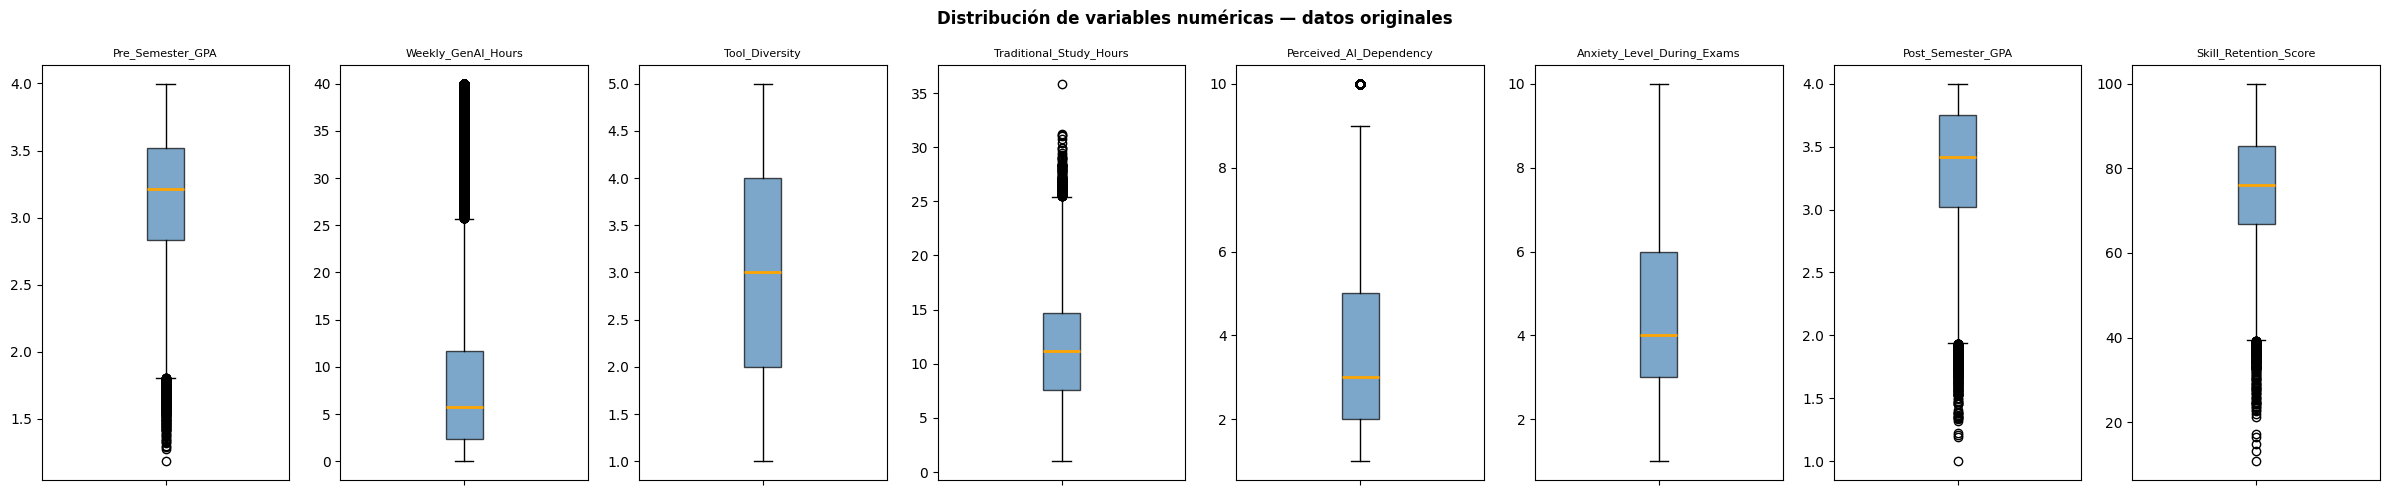

In [7]:
mostrar_boxplots(df, COLUMNAS_NUMERICAS, 'Distribución de variables numéricas — datos originales')

#### 2.3.5 Análisis de valores atípicos (outliers)

El método **IQR (Rango Intercuartílico)** define como valor atípico cualquier punto fuera del rango:

- **Límite inferior:** Q1 − 1.5 × IQR
- **Límite superior:** Q3 + 1.5 × IQR

Se aplica sobre las 8 variables numéricas **antes de cualquier transformación** para determinar si requieren tratamiento. Este análisis responde a la tarea de limpieza indicada en la Guía de Desarrollo F2 (sección 3.5): *"Tratamiento de inconsistencias y valores atípicos si se identifican."*


In [8]:
resumen_outliers = detectar_outliers(df, COLUMNAS_NUMERICAS)
print(resumen_outliers.to_string())

                               Q1     Q3    IQR  Lím. inferior  Lím. superior  N outliers  % del total
Variable                                                                                              
Pre_Semester_GPA             2.83   3.52   0.69           1.80           4.55         328         0.66
Weekly_GenAI_Hours           2.39  11.72   9.33         -11.60          25.72        2583         5.17
Tool_Diversity               2.00   4.00   2.00          -1.00           7.00           0         0.00
Traditional_Study_Hours      7.56  14.71   7.15          -3.17          25.44         161         0.32
Perceived_AI_Dependency      2.00   5.00   3.00          -2.50           9.50         190         0.38
Anxiety_Level_During_Exams   3.00   6.00   3.00          -1.50          10.50           0         0.00
Post_Semester_GPA            3.02   3.75   0.73           1.94           4.84         346         0.69
Skill_Retention_Score       66.82  85.19  18.37          39.26         11

#### Decisión técnica: conservar los valores atípicos

El análisis IQR identifica puntos fuera del rango [Q1 − 1.5·IQR, Q3 + 1.5·IQR] en algunas variables. Sin embargo, **no se aplica eliminación ni imputación** por las siguientes razones técnicas:

| Argumento | Detalle |
|---|---|
| **Dataset sintético** | Los datos fueron generados con rangos predefinidos. Los extremos son parte del diseño, no errores de captura. |
| **Valores dentro del dominio válido** | `Weekly_GenAI_Hours` tiene techo en 40 h/sem; `Skill_Retention_Score` va de 0 a 100; todos los puntos extremos están dentro de los límites declarados por la fuente. |
| **Son informativos** | Representan perfiles reales en los extremos: estudiantes con uso muy intensivo de IA o con retención muy baja/alta. Eliminarlos sesgaría el dataset hacia el centro. |
| **Sin valores nulos** | La guía F2 (sección 3.3) enfatiza el manejo de NA. Al no existir nulos, la limpieza se reduce a la revisión de atípicos, que resultan válidos. |

**Conclusión:** Los valores identificados como estadísticamente atípicos son representativos del fenómeno estudiado. Se conservan íntegramente para no perder información en el modelado.


#### 2.3.6 Frecuencia de categorías

La función `show_categories` muestra el conteo de cada categoría en las columnas de tipo `object`. Permite verificar que no existan valores inesperados ni categorías con frecuencia muy baja antes de aplicar One-Hot Encoding.

In [9]:
show_categories(df)


Major_Category:
Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933

Year_of_Study:
Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430

Primary_Use_Case:
Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340

Prompt_Engineering_Skill:
Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809

Institutional_Policy:
Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788

Burnout_Risk_Level:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487


#### 2.3.7 Análisis de asimetría (skewness)

El skewness mide cuánto se aleja la distribución de una forma simétrica. Este análisis fundamenta la elección entre `StandardScaler` y `MinMaxScaler`.

**Criterio aplicado:**
- |skewness| < 0.5 → distribución aproximadamente simétrica → **StandardScaler**
- 0.5 ≤ |skewness| < 1.0 → asimetría moderada → se evalúa caso a caso
- |skewness| ≥ 1.0 → asimetría pronunciada → **MinMaxScaler**

Para variables de escala Likert (1–10) o discreta acotada (1–5) se aplica **MinMaxScaler** independientemente del skewness, ya que el rango está definido por el dominio.

In [10]:
tabla_skewness = compute_skewness(df, COLUMNAS_NUMERICAS)

Análisis de skewness — criterio de selección de escalador:
---------------------------------------------------------------------------
                  Variable  Skewness                             Interpretación               Escalador_Recomendado
          Pre_Semester_GPA   -0.6020                         Asimetría moderada StandardScaler (revisar histograma)
        Weekly_GenAI_Hours    1.6098                      Asimetría pronunciada                        MinMaxScaler
            Tool_Diversity    0.1668 Escala discreta acotada (dominio definido)                        MinMaxScaler
   Traditional_Study_Hours    0.1301                  Aproximadamente simétrica                      StandardScaler
   Perceived_AI_Dependency    0.6554 Escala discreta acotada (dominio definido)                        MinMaxScaler
Anxiety_Level_During_Exams    0.3617 Escala discreta acotada (dominio definido)                        MinMaxScaler
         Post_Semester_GPA   -0.6751                 

### 2.4 Limpieza básica de datos

Limpiar los datos significa dejar los datos completos y consistentes. Tomamos dos decisiones, cada
una justificada técnicamente:

**1) Eliminar `Student_ID`:** Es un identificador único sin información predictiva. Mantenerlo podría introducir fuga de datos en modelos que asignen peso a identificadores correlacionados con el orden de registro.

**2) Sin imputación de nulos:** El dataset no contiene valores nulos en ninguna columna, verificado con `show_nulos` en la sección anterior.

In [11]:
df = drop_id_column(df,'Student_ID')
df.head()

[OK] Columna Student_ID eliminada. Shape resultante: (50000, 15)


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


### 2.5 Conversión de variable booleana

`Paid_Subscription` es de tipo `bool`. La conversión explícita a `int64` garantiza compatibilidad con todos los estimadores de scikit-learn.

In [12]:
df = cast_bool_to_int(df)
df.head()

[INFO] Paid_Subscription — dtype antes: bool
[INFO] Paid_Subscription — dtype despues: int64
[OK] Paid_Subscription convertida a int64. Distribución: {0: 28846, 1: 21154}


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,Medical,Junior,3.821,1.12,Ideation,Advanced,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,0,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


### 2.6. Codificación de variables ordinales

Las variables ordinales poseen una relación de orden inherente que los modelos pueden aprovechar. Se asignan enteros consecutivos según jerarquía real.

Aplicar **One-Hot Encoding** a variables ordinales destruiría la relación de orden y expandiría innecesariamente el espacio de features.

| Variable | Tipo | Mapping |
|---|---|---|
| `Year_of_Study` | Ordinal | Freshman=0, Sophomore=1, Junior=2, Senior=3, Graduate=4 |
| `Prompt_Engineering_Skill` | Ordinal | Beginner=0, Intermediate=1, Advanced=2 |
| `Burnout_Risk_Level` | Ordinal (target clasificación) | Low=0, Medium=1, High=2 |

Se ejecuta la función `encode_ordinal` para las columnas: 

- `Year_of_Study`
- `Prompt_Engineering_Skill`
- `Burnout_Risk_Level`

In [13]:
# Year_of_Study: orden académico natural
df = encode_ordinal(df, 'Year_of_Study',
                    order=['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'])

# Prompt_Engineering_Skill: progresión de dominio
df = encode_ordinal(df, 'Prompt_Engineering_Skill',
                    order=['Beginner', 'Intermediate', 'Advanced'])

# Burnout_Risk_Level: target de clasificación — NO se escala
df = encode_ordinal(df, 'Burnout_Risk_Level',
                    order=['Low', 'Medium', 'High'])

print('\nDistribución post-codificación ordinal:')
print(df[['Year_of_Study', 'Prompt_Engineering_Skill', 'Burnout_Risk_Level']]
      .apply(lambda c: c.value_counts()).T)
df.head()

[OK] Year_of_Study codificada. Mapping: {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4}
[OK] Prompt_Engineering_Skill codificada. Mapping: {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
[OK] Burnout_Risk_Level codificada. Mapping: {'Low': 0, 'Medium': 1, 'High': 2}

Distribución post-codificación ordinal:
                                0        1        2        3       4
Year_of_Study             11031.0   9860.0  11045.0  10634.0  7430.0
Prompt_Engineering_Skill  18495.0  17696.0  13809.0      NaN     NaN
Burnout_Risk_Level        16369.0  21144.0  12487.0      NaN     NaN


,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,Humanities,3,2.418,23.31,Copywriting/Drafting,0,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,2
1,Medical,2,3.821,1.12,Ideation,2,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,0
2,Business,0,3.398,21.26,Summarizing_Reading,0,2,0,10.35,5,Strict_Ban,9,3.499,73.93,1
3,Business,3,3.789,1.82,Copywriting/Drafting,1,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,1
4,STEM,1,3.635,9.29,Debugging/Troubleshooting,2,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,1


### 2.7. Codificación One-Hot de variables nominales

Las variables nominales no tienen un orden inherente entre sus categorías. Si les asignáramos números enteros (0, 1, 2...), el modelo asumiría falsamente una jerarquía. **One-Hot Encoding** resuelve esto creando una columna binaria por cada categoría: el modelo las trata como equivalentes en rango.

| Variable | Categorías (orden alfabético) | Columnas resultantes |
|---|---|---|
| `Major_Category` | Arts, Business, Humanities, Medical, STEM | 5 columnas |
| `Primary_Use_Case` | Copywriting/Drafting, Debugging/Troubleshooting, Direct_Answer_Generation, Ideation, Summarizing_Reading | 5 columnas |
| `Institutional_Policy` | Actively_Encouraged, Allowed_With_Citation, Strict_Ban | 3 columnas |

El orden de las columnas sigue el orden **alfabético** de las categorías, criterio interno de `LabelEncoder`.

#### 2.7.1 `Major_Category`

Categorías en orden alfabético: `Arts`, `Business`, `Humanities`, `Medical`, `STEM` → cinco columnas binarias.

In [14]:
df = codificar_one_hot(df, 'Major_Category',
                       ['major_Arts', 'major_Business', 'major_Humanities',
                        'major_Medical', 'major_STEM'])
df.head()

[OK] Major_Category → ['major_Arts', 'major_Business', 'major_Humanities', 'major_Medical', 'major_STEM']


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,major_Arts,major_Business,major_Humanities,major_Medical,major_STEM
0,3,2.418,23.31,Copywriting/Drafting,0,1,1,8.13,5,Allowed_With_Citation,6,2.393,86.44,2,0,0,1,0,0
1,2,3.821,1.12,Ideation,2,5,0,16.65,3,Allowed_With_Citation,9,3.696,69.39,0,0,0,0,1,0
2,0,3.398,21.26,Summarizing_Reading,0,2,0,10.35,5,Strict_Ban,9,3.499,73.93,1,0,1,0,0,0
3,3,3.789,1.82,Copywriting/Drafting,1,4,0,15.23,2,Allowed_With_Citation,2,4.000,63.58,1,0,1,0,0,0
4,1,3.635,9.29,Debugging/Troubleshooting,2,4,0,12.55,4,Allowed_With_Citation,4,3.798,100.00,1,0,0,0,0,1


#### 2.7.2 `Primary_Use_Case`

Categorías en orden alfabético: `Copywriting/Drafting`, `Debugging/Troubleshooting`, `Direct_Answer_Generation`, `Ideation`, `Summarizing_Reading` → cinco columnas binarias.

In [15]:
df = codificar_one_hot(df, 'Primary_Use_Case',
                       ['use_Copywriting_Drafting', 'use_Debugging_Troubleshooting',
                        'use_Direct_Answer_Generation', 'use_Ideation',
                        'use_Summarizing_Reading'])
df.head()

[OK] Primary_Use_Case → ['use_Copywriting_Drafting', 'use_Debugging_Troubleshooting', 'use_Direct_Answer_Generation', 'use_Ideation', 'use_Summarizing_Reading']


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,...,major_Arts,major_Business,major_Humanities,major_Medical,major_STEM,use_Copywriting_Drafting,use_Debugging_Troubleshooting,use_Direct_Answer_Generation,use_Ideation,use_Summarizing_Reading
0,3,2.418,23.31,0,1,1,8.13,5,Allowed_With_Citation,6,...,0,0,1,0,0,1,0,0,0,0
1,2,3.821,1.12,2,5,0,16.65,3,Allowed_With_Citation,9,...,0,0,0,1,0,0,0,0,1,0
2,0,3.398,21.26,0,2,0,10.35,5,Strict_Ban,9,...,0,1,0,0,0,0,0,0,0,1
3,3,3.789,1.82,1,4,0,15.23,2,Allowed_With_Citation,2,...,0,1,0,0,0,1,0,0,0,0
4,1,3.635,9.29,2,4,0,12.55,4,Allowed_With_Citation,4,...,0,0,0,0,1,0,1,0,0,0


#### 2.7.3 `Institutional_Policy`

Categorías en orden alfabético: `Actively_Encouraged`, `Allowed_With_Citation`, `Strict_Ban` → tres columnas binarias.

In [16]:
df = codificar_one_hot(df, 'Institutional_Policy',
                       ['policy_Actively_Encouraged', 'policy_Allowed_With_Citation',
                        'policy_Strict_Ban'])
df.head()

[OK] Institutional_Policy → ['policy_Actively_Encouraged', 'policy_Allowed_With_Citation', 'policy_Strict_Ban']


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,...,major_Medical,major_STEM,use_Copywriting_Drafting,use_Debugging_Troubleshooting,use_Direct_Answer_Generation,use_Ideation,use_Summarizing_Reading,policy_Actively_Encouraged,policy_Allowed_With_Citation,policy_Strict_Ban
0,3,2.418,23.31,0,1,1,8.13,5,6,2.393,...,0,0,1,0,0,0,0,0,1,0
1,2,3.821,1.12,2,5,0,16.65,3,9,3.696,...,1,0,0,0,0,1,0,0,1,0
2,0,3.398,21.26,0,2,0,10.35,5,9,3.499,...,0,0,0,0,0,0,1,0,0,1
3,3,3.789,1.82,1,4,0,15.23,2,2,4.000,...,0,0,1,0,0,0,0,0,1,0
4,1,3.635,9.29,2,4,0,12.55,4,4,3.798,...,0,1,0,1,0,0,0,0,1,0


### 2.8. Escalamiento con StandardScaler

El escalamiento lleva todas las variables numéricas al mismo rango de magnitud. Sin él, variables con rangos grandes (como `Skill_Retention_Score`, de 0 a 100) dominarían sobre variables de rango pequeño (como `Pre_Semester_GPA`, de 1 a 4), sesgando los modelos de aprendizaje automático.

El escalador aplicado a cada variable se determinó en la sección 3.7 según su distribución:

**`StandardScaler`**: Transforma cada variable para que tenga media = 0 y desviación estándar = 1, mediante la fórmula `z = (x − μ) / σ`. Se aplica a variables con distribución aproximadamente simétrica o asimetría moderada.

**`MinMaxScaler`** : Comprime cada variable al rango [0, 1], mediante la fórmula `x' = (x − min) / (max − min)`. Se aplica a variables de escala discreta acotada y a `Weekly_GenAI_Hours` por su asimetría pronunciada.

| Variable | Escalador |
|---|---|
| `Pre_Semester_GPA` | `StandardScaler` |
| `Traditional_Study_Hours` | `StandardScaler` |
| `Post_Semester_GPA` | `StandardScaler` |
| `Skill_Retention_Score` | `StandardScaler` |
| `Weekly_GenAI_Hours` | `MinMaxScaler` |
| `Tool_Diversity` | `MinMaxScaler` |
| `Perceived_AI_Dependency` | `MinMaxScaler` |
| `Anxiety_Level_During_Exams` | `MinMaxScaler` |

**Variables que no se escalan:**
- `Year_of_Study`, `Prompt_Engineering_Skill`, `Burnout_Risk_Level`: variables ordinales codificadas como enteros.
- `Paid_Subscription` y columnas One-Hot Encoding: ya son binarias (0/1).

La columna `Post_Semester_GPA` se escala en esta fase para entregar el dataset completamente procesado. Al momento de definir X e y en el modelado se puede excluir si se desean predicciones en la escala original (1-4).

In [17]:
df, scaler_std, scaler_mm = escalar_caracteristicas(df, COLS_STANDARD, COLS_MINMAX)
df.head()

[OK] Pre_Semester_GPA               ==> StandardScaler | media=-0.0000, std=1.0000
[OK] Traditional_Study_Hours        ==> StandardScaler | media=0.0000, std=1.0000
[OK] Post_Semester_GPA              ==> StandardScaler | media=0.0000, std=1.0000
[OK] Skill_Retention_Score          ==> StandardScaler | media=0.0000, std=1.0000
[OK] Weekly_GenAI_Hours             ==> MinMaxScaler  | min=0.0000, max=1.0000
[OK] Tool_Diversity                 ==> MinMaxScaler  | min=0.0000, max=1.0000
[OK] Perceived_AI_Dependency        ==> MinMaxScaler  | min=0.0000, max=1.0000
[OK] Anxiety_Level_During_Exams     ==> MinMaxScaler  | min=0.0000, max=1.0000


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,...,major_Medical,major_STEM,use_Copywriting_Drafting,use_Debugging_Troubleshooting,use_Direct_Answer_Generation,use_Ideation,use_Summarizing_Reading,policy_Actively_Encouraged,policy_Allowed_With_Citation,policy_Strict_Ban
0,3,-1.520524,0.58275,0,0.00,1,-0.597178,0.444444,0.555556,-1.929316,...,0,0,1,0,0,0,0,0,1,0
1,2,1.409415,0.02800,2,1.00,0,1.055146,0.222222,0.888889,0.699462,...,1,0,0,0,0,1,0,0,1,0
2,0,0.526048,0.53150,0,0.25,0,-0.166642,0.444444,0.888889,0.302018,...,0,0,0,0,0,0,1,0,0,1
3,3,1.342588,0.04550,1,0.75,0,0.779759,0.111111,0.111111,1.312776,...,0,0,1,0,0,0,0,0,1,0
4,1,1.020984,0.23225,2,0.75,0,0.260014,0.333333,0.333333,0.905245,...,0,1,0,1,0,0,0,0,1,0


Verificamos visualmente que las 8 variables escaladas quedan centradas en 0. La línea naranja (mediana) debería estar cercana a 0 en todas.


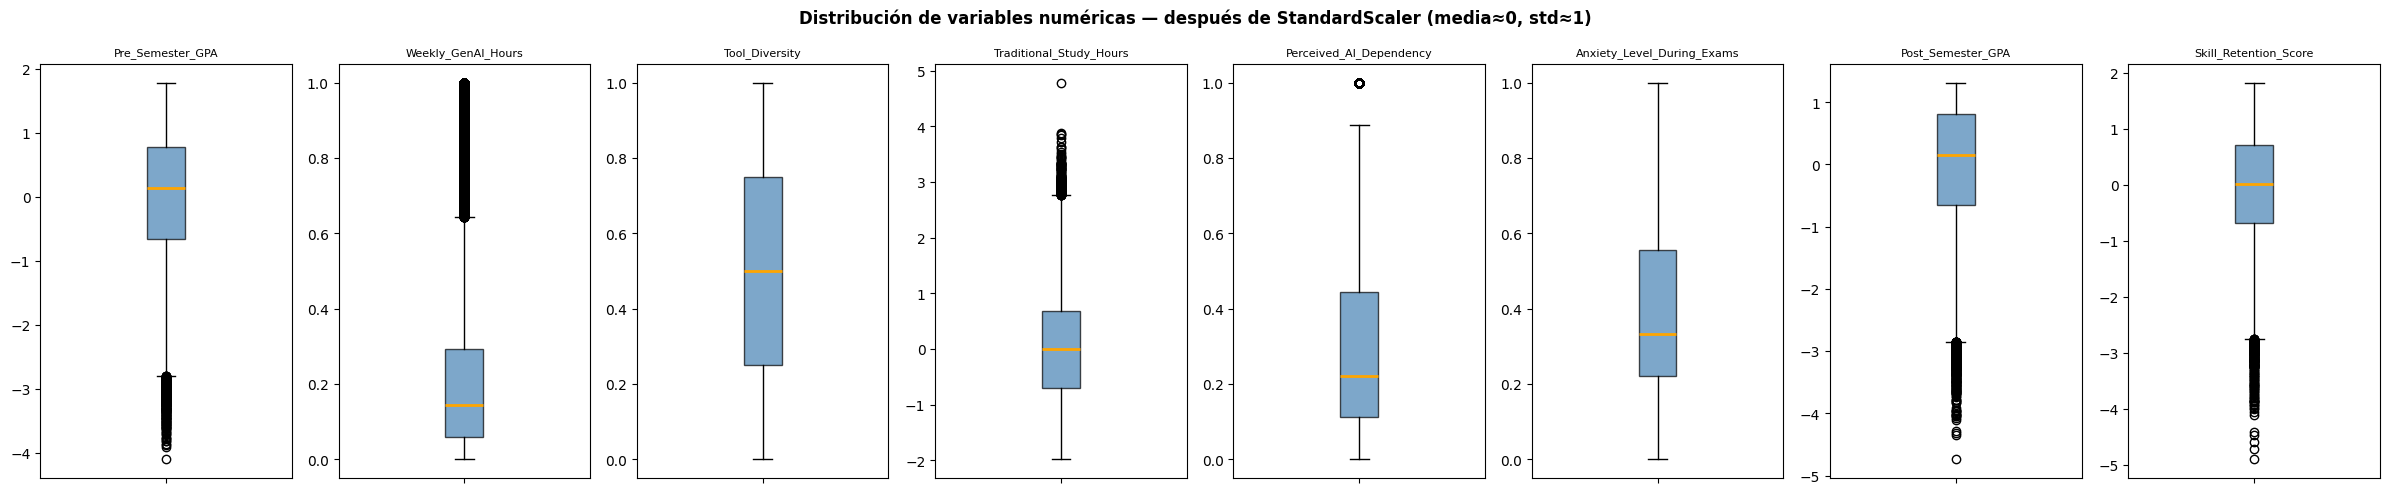

In [18]:
mostrar_boxplots(df, COLUMNAS_NUMERICAS, 'Distribución de variables numéricas — después de StandardScaler (media≈0, std≈1)')

### 2.9. Validación técnica del pipeline

Antes de exportar verificamos que el pipeline produjo exactamente lo esperado. Usamos `assert`: si alguna condición no se cumple, Python lanza un `AssertionError` que detiene la ejecución e indica qué revisar.

Las verificaciones cubren:
1. **Sin valores nulos**: El dataset procesado no debe tener valores nulos.
2. **Sin duplicados**: Ninguna fila debe repetirse.
3. **Todas las columnas son numéricas**: Ninguna columna de texto debe haber quedado sin codificar.
4. **Variables escaladas con media ≈ 0 y std ≈ 1** — validación del **StandardScaler**.
5. **Columnas One-Hot válidas**: Solo deben contener 0 y 1.
6. **Variables ordinales codificadas correctamente**: `Burnout_Risk_Level` en {0,1,2}.
7. **Número de columnas correcto**: 25 columnas en total (16 originales − 1 ID − 3 nominales + 13 **One-Hot Encoding**).

In [19]:
# 1. Sin valores nulos
assert df.isnull().sum().sum() == 0, "Hay valores nulos en el dataset procesado."
print('[OK] Sin valores nulos.')

# 2. Sin duplicados
assert df.duplicated().sum() == 0, "Hay filas duplicadas."
print('[OK] Sin filas duplicadas.')

# 3. Todas las columnas son numéricas
no_numericas = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
assert not no_numericas, f"Columnas no numéricas: {no_numericas}"
print('[OK] Todas las columnas son numéricas.')

# 4a. Variables StandardScaler: media ≈ 0, std ≈ 1
for col in COLS_STANDARD:
    assert abs(df[col].mean()) < 1e-6, f"{col}: media no es ≈ 0 (media={df[col].mean():.6f})."
    assert abs(df[col].std() - 1.0) < 1e-2, f"{col}: std no es ≈ 1 (std={df[col].std():.6f})."
print('[OK] Variables StandardScaler estandarizadas (media≈0, std≈1).')

# 4b. Variables MinMaxScaler: rango [0, 1]
for col in COLS_MINMAX:
    assert df[col].min() >= 0.0, f"{col}: mínimo fuera de rango (min={df[col].min():.6f})."
    assert df[col].max() <= 1.0, f"{col}: máximo fuera de rango (max={df[col].max():.6f})."
print('[OK] Variables MinMaxScaler normalizadas (rango [0, 1]).')

# 5. Columnas One-Hot solo contienen 0 y 1
ohe_cols = [c for c in df.columns if c.startswith(('major_', 'use_', 'policy_'))]
for col in ohe_cols:
    assert set(df[col].unique()).issubset({0, 1}), f"{col}: valores fuera de {{0, 1}}."
print(f'[OK] {len(ohe_cols)} columnas One-Hot contienen solo 0 y 1.')

# 6. Burnout_Risk_Level solo contiene 0, 1, 2
assert set(df['Burnout_Risk_Level'].unique()).issubset({0, 1, 2}), \
    "Burnout_Risk_Level tiene valores inesperados."
print('[OK] Burnout_Risk_Level codificado correctamente (0=Low, 1=Medium, 2=High).')

# 7. Número de columnas esperado
COLS_ESPERADAS = 25
assert df.shape[1] == COLS_ESPERADAS, \
    f"Se esperaban {COLS_ESPERADAS} columnas, hay {df.shape[1]}."
print(f'[OK] Dataset tiene {df.shape[1]} columnas.')

print(f'\nDimensiones finales: {df.shape}')
print('\nColumnas del dataset procesado:')
for i, col in enumerate(df.columns.tolist(), 1):
    print(f'  {i:2d}. {col}')

[OK] Sin valores nulos.
[OK] Sin filas duplicadas.
[OK] Todas las columnas son numéricas.
[OK] Variables StandardScaler estandarizadas (media≈0, std≈1).
[OK] Variables MinMaxScaler normalizadas (rango [0, 1]).
[OK] 13 columnas One-Hot contienen solo 0 y 1.
[OK] Burnout_Risk_Level codificado correctamente (0=Low, 1=Medium, 2=High).
[OK] Dataset tiene 25 columnas.

Dimensiones finales: (50000, 25)

Columnas del dataset procesado:
   1. Year_of_Study
   2. Pre_Semester_GPA
   3. Weekly_GenAI_Hours
   4. Prompt_Engineering_Skill
   5. Tool_Diversity
   6. Paid_Subscription
   7. Traditional_Study_Hours
   8. Perceived_AI_Dependency
   9. Anxiety_Level_During_Exams
  10. Post_Semester_GPA
  11. Skill_Retention_Score
  12. Burnout_Risk_Level
  13. major_Arts
  14. major_Business
  15. major_Humanities
  16. major_Medical
  17. major_STEM
  18. use_Copywriting_Drafting
  19. use_Debugging_Troubleshooting
  20. use_Direct_Answer_Generation
  21. use_Ideation
  22. use_Summarizing_Reading
  23.

### 2.10. Exportación del dataset procesado

El dataset final se guarda en `data/processed/` para su uso en la Fase 3 (Modelado). El archivo CSV resultante contiene todas las transformaciones aplicadas y está listo para entrenar modelos de regresión (`Post_Semester_GPA`) y clasificación (`Burnout_Risk_Level`).

In [20]:
file_path_exported = '../data/processed/ai_student_impact_processed_f2.csv'
export_processed(df,file_path_exported)
print('\nEstadísticas finales:')
df.describe()

[OK] Dataset procesado exportado a: ../data/processed/ai_student_impact_processed_f2.csv
     Dimensiones: 50000 filas × 25 columnas
     Memoria: 7226.7 KB

Estadísticas finales:


,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,...,major_Medical,major_STEM,use_Copywriting_Drafting,use_Debugging_Troubleshooting,use_Direct_Answer_Generation,use_Ideation,use_Summarizing_Reading,policy_Actively_Encouraged,policy_Allowed_With_Citation,policy_Strict_Ban
count,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,5.000000e+04,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.871440,-2.243894e-16,0.210694,0.906280,0.450065,0.423080,1.335110e-16,0.278373,0.363418,1.714895e-16,...,0.129520,0.301180,0.240220,0.245900,0.126800,0.214420,0.172660,0.299760,0.504480,0.195760
std,1.367578,1.000010e+00,0.206737,0.798317,0.297005,0.494053,1.000010e+00,0.202312,0.238230,1.000010e+00,...,0.335778,0.458775,0.427221,0.430624,0.332752,0.410423,0.377957,0.458157,0.499985,0.396789
min,0.000000,-4.099622e+00,0.000000,0.000000,0.000000,0.000000,-1.979932e+00,0.000000,0.000000,-4.739667e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,-6.517753e-01,0.059750,0.000000,0.250000,0.000000,-7.077203e-01,0.111111,0.222222,-6.567898e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.334399e-01,0.145000,1.000000,0.500000,0.000000,-5.676663e-03,0.222222,0.333333,1.446546e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,3.000000,7.829132e-01,0.293000,2.000000,0.750000,1.000000,6.789129e-01,0.444444,0.555556,8.063884e-01,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,4.000000,1.779051e+00,1.000000,2.000000,1.000000,1.000000,4.780632e+00,1.000000,1.000000,1.312776e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 3. Arquitectura Programación Orientada Al Objeto

#### Diagrama de clases (descripción textual)

| Componente | Responsabilidad |
|---|---|
| `GestorDatos` | Carga el dataset raw y guarda dataset processed: define `cargar_datos(df)` y `guardar_datos(df)`|
| `Transformador` (ABC) | Contrato común: define `aplicar(df)` como método abstracto |
| `EliminarColumna` | Elimina Student_ID (sin valor predictivo) |
| `CastBooleano` | Convierte `Paid_Subscription` bool → int64 |
| `CodificadorOrdinal` | Mapeo explícito para variables con jerarquía real |
| `CodificadorOneHot` | OHE para variables nominales sin orden inherente |
| `EscaladoZScore` | StandardScaler para distribuciones simétricas |
| `EscaladoMinMax` | MinMaxScaler para escalas discretas o asimétricas |
| `Pipeline` | Orquestador: aplica etapas en orden via polimorfismo |
| `Preprocesador` | Encapsula F2 completo con estado interno protegido |
| `BuscadorPerfilRiesgo` | Búsqueda lineal O(n) y vectorizada |
| `OrdenadorMergeSort` | Merge Sort recursivo O(n log n) |
| `DetectorOutliersIQR` | Detección de atípicos por IQR |
| `AnalizadorRiesgo` | Orquestador del núcleo algorítmico F3 |

#### Principios de Programación Orientada al Objeto aplicados
- **Encapsulamiento**: Estado interno `self._df` protegido; solo accesible via métodos.
- **Herencia**: Todas las transformaciones heredan de `Transformador` (ABC).
- **Polimorfismo**: `Pipeline.ejecutar()` llama `etapa.aplicar(df)` sin conocer la subclase.
- **Responsabilidad única**: Cada clase/método hace exactamente una cosa.

#### 3.1 Carga del dataset raw
Se carga el dataset original desde `data/raw/`. El archivo **no se modifica** en ningún
momento del pipeline, respetando la separación entre datos raw y procesados establecida en la fase 2.

In [21]:
gd = GestorDatos("../data/raw/ai_student_impact_dataset.csv","../data/processed/ai_student_impact_processed_poo.csv")
df_raw = gd.cargar_datos()
df_raw.head()

[OK] Datos cargados exitosamente desde ../data/raw/ai_student_impact_dataset.csv


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


### 3.2. Pipeline de preprocesamiento (Fase 2 a POO)

Las funciones de la fase2 se reorganizan como métodos de `Preprocesador`. El encadenamiento
fluido (`prep.eliminar_id().cast_bool()...`) es posible porque cada método devuelve `self`.


In [22]:
# *** Ejecución del pipeline completo ***
prep = Preprocesador(df_raw)

df_procesado = (prep
    .eliminar_id()
    .cast_bool()
    .codificar_ordinales()
    .codificar_nominales()
    .escalar()
    .validar()
    .resultado()
)

print(f"\nShape final: {df_procesado.shape}")
df_procesado.head()


[OK] EliminarColumna: 'Student_ID' eliminada. Shape: (50000, 15)
[OK] CastBooleano: 'Paid_Subscription' → int64. Distribución: {0: 28846, 1: 21154}
[OK] CodificadorOrdinal: 'Year_of_Study' → {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4}
[OK] CodificadorOrdinal: 'Prompt_Engineering_Skill' → {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
[OK] CodificadorOrdinal: 'Burnout_Risk_Level' → {'Low': 0, 'Medium': 1, 'High': 2}
[OK] CodificadorOneHot: 'Major_Category' → ['major_Arts', 'major_Business', 'major_Humanities', 'major_Medical', 'major_STEM']
[OK] CodificadorOneHot: 'Primary_Use_Case' → ['use_Copywriting_Drafting', 'use_Debugging_Troubleshooting', 'use_Direct_Answer_Generation', 'use_Ideation', 'use_Summarizing_Reading']
[OK] CodificadorOneHot: 'Institutional_Policy' → ['policy_Actively_Encouraged', 'policy_Allowed_With_Citation', 'policy_Strict_Ban']
[OK] EscaladoZScore: 'Pre_Semester_GPA' → media=-0.0000, std=1.0000
[OK] EscaladoZScore: 'Traditional_Study

,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,...,major_Medical,major_STEM,use_Copywriting_Drafting,use_Debugging_Troubleshooting,use_Direct_Answer_Generation,use_Ideation,use_Summarizing_Reading,policy_Actively_Encouraged,policy_Allowed_With_Citation,policy_Strict_Ban
0,3,-1.520524,0.58275,0,0.00,1,-0.597178,0.444444,0.555556,-1.929316,...,0,0,1,0,0,0,0,0,1,0
1,2,1.409415,0.02800,2,1.00,0,1.055146,0.222222,0.888889,0.699462,...,1,0,0,0,0,1,0,0,1,0
2,0,0.526048,0.53150,0,0.25,0,-0.166642,0.444444,0.888889,0.302018,...,0,0,0,0,0,0,1,0,0,1
3,3,1.342588,0.04550,1,0.75,0,0.779759,0.111111,0.111111,1.312776,...,0,0,1,0,0,0,0,0,1,0
4,1,1.020984,0.23225,2,0.75,0,0.260014,0.333333,0.333333,0.905245,...,0,1,0,1,0,0,0,0,1,0


#### 3.3 Pipeline alternativo con composición explícita

Demostración del patrón `Pipeline`: lista de etapas intercambiables sin modificar el orquestador.


In [23]:
# *** Pipeline con composición de Transformadores ***
etapas = [
    EliminadorColumna("Student_ID"),
    CastBooleano("Paid_Subscription"),
    CodificadorOrdinal("Year_of_Study",
        ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]),
    CodificadorOrdinal("Prompt_Engineering_Skill",
        ["Beginner", "Intermediate", "Advanced"]),
    CodificadorOrdinal("Burnout_Risk_Level",
        ["Low", "Medium", "High"]),
    CodificadorOneHot("Major_Category",
        ["major_Arts","major_Business","major_Humanities","major_Medical","major_STEM"]),
    CodificadorOneHot("Primary_Use_Case",
        ["use_Copywriting_Drafting","use_Debugging_Troubleshooting",
         "use_Direct_Answer_Generation","use_Ideation","use_Summarizing_Reading"]),
    CodificadorOneHot("Institutional_Policy",
        ["policy_Actively_Encouraged","policy_Allowed_With_Citation","policy_Strict_Ban"]),
    EscaladoZScore(["Pre_Semester_GPA","Traditional_Study_Hours",
                    "Post_Semester_GPA","Skill_Retention_Score"]),
    EscaladoMinMax(["Weekly_GenAI_Hours","Tool_Diversity",
                    "Perceived_AI_Dependency","Anxiety_Level_During_Exams"]),
]

pipe = Pipeline(etapas)
df_pipe = pipe.ejecutar(df_raw.copy())
print(f"\nShape (Pipeline alternativo): {df_pipe.shape}")

# Verificar equivalencia con Preprocesador
assert df_procesado.shape == df_pipe.shape, "Divergencia entre ambos pipelines."
print("[OK] Ambos pipelines producen el mismo shape.")


[INFO] Pipeline iniciado — 10 etapas.

  [1/10] EliminadorColumna()
[OK] EliminarColumna: 'Student_ID' eliminada. Shape: (50000, 15)

  [2/10] CastBooleano()
[OK] CastBooleano: 'Paid_Subscription' → int64. Distribución: {0: 28846, 1: 21154}

  [3/10] CodificadorOrdinal()
[OK] CodificadorOrdinal: 'Year_of_Study' → {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4}

  [4/10] CodificadorOrdinal()
[OK] CodificadorOrdinal: 'Prompt_Engineering_Skill' → {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}

  [5/10] CodificadorOrdinal()
[OK] CodificadorOrdinal: 'Burnout_Risk_Level' → {'Low': 0, 'Medium': 1, 'High': 2}

  [6/10] CodificadorOneHot()
[OK] CodificadorOneHot: 'Major_Category' → ['major_Arts', 'major_Business', 'major_Humanities', 'major_Medical', 'major_STEM']

  [7/10] CodificadorOneHot()
[OK] CodificadorOneHot: 'Primary_Use_Case' → ['use_Copywriting_Drafting', 'use_Debugging_Troubleshooting', 'use_Direct_Answer_Generation', 'use_Ideation', 'use_Summarizing_Read

### 4. Validación técnica del pipeline

Se prueba el pipeline en tres escenarios: caso normal, caso límite (un solo registro) y excepción.

In [24]:
# *** Caso 1: Normal ***
print("***CASO NORMAL***")
assert df_procesado.isnull().sum().sum() == 0, "Hay valores nulos."
assert df_procesado.duplicated().sum() == 0, "Hay duplicados."
no_num = [c for c in df_procesado.columns
          if not pd.api.types.is_numeric_dtype(df_procesado[c])]
assert not no_num, f"Columnas no numéricas: {no_num}"
assert df_procesado.shape[1] == 25, f"Se esperaban 25 cols, hay {df_procesado.shape[1]}."
ohe_cols = [c for c in df_procesado.columns if c.startswith(("major_","use_","policy_"))]
for col in ohe_cols:
    assert set(df_procesado[col].unique()).issubset({0, 1})
assert set(df_procesado["Burnout_Risk_Level"].unique()).issubset({0, 1, 2})
print(f"[OK] 7 assertions superadas. Shape: {df_procesado.shape}")

# *** Caso 2: Límite — un solo registro ***
print("\n*** CASO LÍMITE (1 registro) ***")
df_1fila = df_raw.head(1).copy()
try:
    df_1f_proc = (Preprocesador(df_1fila)
                  .eliminar_id().cast_bool()
                  .codificar_ordinales().codificar_nominales()
                  .escalar().resultado())
    assert df_1f_proc.shape == (1, 25)
    print(f"[OK] 1 registro procesado correctamente. Shape: {df_1f_proc.shape}")
except Exception as e:
    print(f"[ERROR] {e}")

# *** Caso 3: Excepción — columna inexistente ***
print("\n*** CASO EXCEPCIÓN (columna inexistente) ***")
try:
    EscaladoZScore(["columna_inexistente"]).aplicar(df_procesado.copy())
except KeyError as e:
    print(f"[OK] KeyError capturado correctamente: {e}")

# *** Caso 4: Excepción — nombres OHE incorrectos ***
print("\n*** CASO EXCEPCIÓN (nombres One Hot Encoder incorrectos) ***")
try:
    CodificadorOneHot("Institutional_Policy", ["solo_un_nombre"]).aplicar(df_raw.head(10).copy())
except ValueError as e:
    print(f"[OK] ValueError capturado correctamente: {e}")


***CASO NORMAL***
[OK] 7 assertions superadas. Shape: (50000, 25)

*** CASO LÍMITE (1 registro) ***
[OK] EliminarColumna: 'Student_ID' eliminada. Shape: (1, 15)
[OK] CastBooleano: 'Paid_Subscription' → int64. Distribución: {1: 1}
[OK] CodificadorOrdinal: 'Year_of_Study' → {'Freshman': 0, 'Sophomore': 1, 'Junior': 2, 'Senior': 3, 'Graduate': 4}
[OK] CodificadorOrdinal: 'Prompt_Engineering_Skill' → {'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
[OK] CodificadorOrdinal: 'Burnout_Risk_Level' → {'Low': 0, 'Medium': 1, 'High': 2}
[ERROR] Se esperaban 1 nombres para 'Major_Category', se recibieron 5.

*** CASO EXCEPCIÓN (columna inexistente) ***
[OK] KeyError capturado correctamente: "EscaladoZScore: columnas no encontradas: ['columna_inexistente']"

*** CASO EXCEPCIÓN (nombres One Hot Encoder incorrectos) ***
[OK] ValueError capturado correctamente: Se esperaban 3 nombres para 'Institutional_Policy', se recibieron 1.
